# Squat Form Detection — 1D-CNN
**IMU-only · 4-class severity · Raw signal input**

1D Convolutional Neural Network. Learns motion patterns directly from raw IMU windows. Smaller architecture (32→64→32) suited for small dataset.

## Cell 1 — Imports & Config

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
BASE      = r'C:\Users\javie\OneDrive - The University of Texas at Austin\Documents\UT - Spring 2026\Human Signals\Final Project'
BASE_FILT = BASE + r'\Filtered_data'

# ── Rates ──────────────────────────────────────────────────
KINE_HZ   = 100
TARGET_HZ = 29
WIN_SEC   = 2.0     # extended from 1.5s — captures more of each rep
OVERLAP   = 0.75    # 75% overlap — more windows from same data
WIN_LEN   = int(WIN_SEC * TARGET_HZ)
STEP      = int(WIN_LEN * (1 - OVERLAP))

# ── IMU channels (model input only) ───────────────────────
imu_cols = ['ax','ay','az','gx','gy','gz','pitch','roll','yaw']

# ── Label map (right knee toes-shank angle) ────────────────
SHEET_LABEL_R = {
    'R < 7'        : 0,
    '10 > R => 7'  : 1,
    '15 > R => 10' : 2,
    'R => 15'      : 3,
}
LABEL_NAMES = ['correct (<7deg)', 'mild (7-10deg)', 'moderate (10-15deg)', 'severe (>15deg)']
N_CLASSES   = 4

print(f'Window: {WIN_LEN} frames ({WIN_SEC}s @ {TARGET_HZ}Hz)  Step: {STEP} frames')
print(f'IMU channels: {imu_cols}')
print(f'Labels: {LABEL_NAMES}')

Window: 58 frames (2.0s @ 29Hz)  Step: 14 frames
IMU channels: ['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'pitch', 'roll', 'yaw']
Labels: ['correct (<7deg)', 'mild (7-10deg)', 'moderate (10-15deg)', 'severe (>15deg)']


## Cell 2 — Data Loading Functions

In [5]:
def load_kine_from_xlsx(xlsx_path):
    """Load frame sequence and time axis from main sheet of bin xlsx."""
    xl   = pd.read_excel(xlsx_path, sheet_name=0)
    data = xl.iloc[3:].copy()
    data.columns = ['frame', 'L_Knee', 'R_Knee']
    data['frame']  = pd.to_numeric(data['frame'],  errors='coerce')
    data['R_Knee'] = pd.to_numeric(data['R_Knee'], errors='coerce')
    data['L_Knee'] = pd.to_numeric(data['L_Knee'], errors='coerce')
    data = data.dropna(subset=['frame']).reset_index(drop=True)
    data['frame']  = data['frame'].astype(int)
    data = data.sort_values('frame').reset_index(drop=True)
    data['time_s'] = (data['frame'] - 1) / KINE_HZ
    return data

def build_frame_labels(xlsx_path):
    """Build {frame: severity_label} dict from bin sheets (right knee only)."""
    xl = pd.read_excel(xlsx_path, sheet_name=None)
    frame_labels = {}
    for sheet_name, label in SHEET_LABEL_R.items():
        sheet_df = xl[sheet_name]
        data = sheet_df.iloc[3:].copy()
        data.columns = ['frame', 'L_Knee', 'R_Knee']
        data['frame'] = pd.to_numeric(data['frame'], errors='coerce')
        frames = data.dropna(subset=['frame'])['frame'].astype(int).values
        for f in frames:
            frame_labels[f] = label
    return frame_labels

def load_watch_imu(fpath):
    """Load SensorLog CSV and return clean IMU DataFrame."""
    df = pd.read_csv(fpath)
    rename = {
        'loggingTime(txt)'               : 'timestamp',
        'motionUserAccelerationX(G)'      : 'ax',
        'motionUserAccelerationY(G)'      : 'ay',
        'motionUserAccelerationZ(G)'      : 'az',
        'motionRotationRateX(rad/s)'      : 'gx',
        'motionRotationRateY(rad/s)'      : 'gy',
        'motionRotationRateZ(rad/s)'      : 'gz',
        'motionPitch(rad)'                : 'pitch',
        'motionRoll(rad)'                 : 'roll',
        'motionYaw(rad)'                  : 'yaw',
    }
    df = df.rename(columns=rename)
    if 'timestamp' in df.columns:
        df = df[df['timestamp'].astype(str).str.startswith('2026', na=False)].reset_index(drop=True)
    df['t']      = pd.to_datetime(df['timestamp'], format='mixed')
    df['time_s'] = (df['t'] - df['t'].iloc[0]).dt.total_seconds()
    for col in imu_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[['time_s'] + imu_cols].dropna().reset_index(drop=True)

def resample_to_hz(df, time_col, value_cols, target_hz):
    """Resample DataFrame to target_hz using linear interpolation."""
    t_orig = df[time_col].values
    t_new  = np.arange(t_orig[0], t_orig[-1], 1.0 / target_hz)
    out = {'time_s': t_new}
    for col in value_cols:
        f = interp1d(t_orig, df[col].values, kind='linear', fill_value='extrapolate')
        out[col] = f(t_new)
    return pd.DataFrame(out)

print('Data loading functions ready.')

Data loading functions ready.


## Cell 3 — Build Windows (IMU-only, MoCap labels)

In [6]:
# ── Trial registry ─────────────────────────────────────────
# Format: (xlsx_path, imu_csv_path, trial_name, subject_id)
# subject_id used for LOSO cross-validation
# NOTE: 6 good trials = 6 different subjects, 2 bad trials = 2 subjects
TRIAL_REGISTRY = [
    (BASE_FILT + r'\Good_1_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_38_29.csv',
     'Good1', 'S01'),
    (BASE_FILT + r'\Good_2_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_39_59.csv',
     'Good2', 'S02'),
    (BASE_FILT + r'\Good_3_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_41_36.csv',
     'Good3', 'S03'),
    (BASE_FILT + r'\Bad_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260330_14_43_42_bad.csv',
     'Bad1',  'S04'),
    (BASE_FILT + r'\Good_4_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_47_16.csv',
     'Good4', 'S05'),
    (BASE_FILT + r'\Good_5_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_48_50.csv',
     'Good5', 'S06'),
    (BASE_FILT + r'\Good_6_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_50_33.csv',
     'Good6', 'S07'),
    (BASE_FILT + r'\Bad_2_Data_ToesRef_filt.xlsx',
     BASE_FILT + r'\stream_Apple_Watch_260414_15_57_30_bad2.csv',
     'Bad2',  'S08'),
    # ── Pending: Good7 (MoCap on other computer) ──────────────
    # (BASE_FILT + r'\Good_7_Data_ToesRef_filt.xlsx',
    #  BASE_FILT + r'\stream_Apple_Watch_260414_15_54_40.csv',
    #  'Good7', 'S09'),
]

# ── Alignment note ──────────────────────────────────────────
# The Watch records longer than MoCap (subject walks in/out of capture volume).
# Alignment uses the common time overlap window (t_s → t_e).
# The squat phase is identified by the subject stopping walking — visible as
# a drop in IMU accel magnitude to near-gravity level. The MoCap and Watch
# are trimmed to the same overlapping duration. A future improvement would
# be to detect the walk→squat transition as an explicit sync anchor.

X_all, y_all, subj_all = [], [], []

for (xlsx_path, imu_path, trial_name, subj_id) in TRIAL_REGISTRY:
    frame_labels = build_frame_labels(xlsx_path)
    kine         = load_kine_from_xlsx(xlsx_path)
    kine['label']= kine['frame'].map(frame_labels).fillna(0).astype(int)
    imu          = load_watch_imu(imu_path)

    # Resample kine to TARGET_HZ — label uses nearest-neighbor to preserve integers
    kine_rs = resample_to_hz(kine, 'time_s', ['R_Knee', 'L_Knee'], TARGET_HZ)
    label_interp = interp1d(kine['time_s'].values, kine['label'].values,
                             kind='nearest', fill_value='extrapolate')
    kine_rs['label'] = label_interp(kine_rs['time_s'].values).astype(int).clip(0, 3)

    # Common time window (Watch records longer than MoCap)
    t_s   = max(kine_rs['time_s'].min(), imu['time_s'].min())
    t_e   = min(kine_rs['time_s'].max(), imu['time_s'].max())
    tgrid = kine_rs[(kine_rs['time_s']>=t_s)&(kine_rs['time_s']<=t_e)]['time_s'].values
    km    = kine_rs[(kine_rs['time_s']>=t_s)&(kine_rs['time_s']<=t_e)].reset_index(drop=True)

    for col in imu_cols:
        f_i = interp1d(imu['time_s'].values, imu[col].values,
                       kind='linear', fill_value='extrapolate')
        km[col] = f_i(tgrid)

    # Slide windows over IMU only — max severity label per window
    imu_arr   = km[imu_cols].values
    label_arr = km['label'].values

    windows, labels = [], []
    for i in range(0, len(imu_arr) - WIN_LEN, STEP):
        win       = imu_arr[i : i + WIN_LEN]
        win_label = int(label_arr[i : i + WIN_LEN].max())
        windows.append(win)
        labels.append(win_label)

    X_all.append(np.array(windows))
    y_all.append(np.array(labels))
    subj_all.extend([subj_id] * len(windows))

    dist = Counter(labels)
    print(f'{trial_name:6s} ({subj_id}) -> {len(windows):4d} windows | '
          f'0:{dist.get(0,0):4d}  1:{dist.get(1,0):3d}  '
          f'2:{dist.get(2,0):3d}  3:{dist.get(3,0):3d}')

X       = np.concatenate(X_all)
y       = np.concatenate(y_all)
subjects= np.array(subj_all)
N, T, C = X.shape
print(f'\nTotal: {X.shape} | Label dist: {dict(sorted(Counter(y).items()))}')
print(f'Subjects: {sorted(np.unique(subjects))}')

# ── Normalize — fit on full dataset for LOSO, re-fit per fold inside CV ──────
# Global scaler used for the held-out final evaluation only
scaler_global = StandardScaler()
X_norm_global = scaler_global.fit_transform(X.reshape(N, T*C)).reshape(N, T, C)

# ── Stratified hold-out test set (20%) for final evaluation ──────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_norm_global, y))
scaler  = StandardScaler()
X_train = scaler.fit_transform(
    X[train_idx].reshape(len(train_idx), T*C)).reshape(len(train_idx), T, C)
X_test  = scaler.transform(
    X[test_idx].reshape(len(test_idx), T*C)).reshape(len(test_idx), T, C)
y_train = y[train_idx]
y_test  = y[test_idx]
subj_train = subjects[train_idx]
N_CHANNELS = C

class_weights       = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict   = dict(enumerate(class_weights))

joblib.dump(scaler, 'scaler_imu_only.pkl')

# ── Export scaler params as JSON for Watch deployment ─────────────────────────
import json as json_module
scaler_params = {
    'mean' : scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    'feature_names': imu_cols,
    'win_len': WIN_LEN,
    'step'   : STEP,
    'target_hz': TARGET_HZ,
}
with open('scaler_params.json', 'w') as f:
    json_module.dump(scaler_params, f, indent=2)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
for lbl, name in enumerate(LABEL_NAMES):
    tr = np.sum(y_train==lbl); te = np.sum(y_test==lbl)
    print(f'  {lbl} {name:30s}: train={tr:4d}  test={te:3d}')
print(f'Class weights: {[round(float(w),2) for w in class_weights]}')
print('Scaler saved -> scaler_imu_only.pkl')
print('Scaler params saved -> scaler_params.json  (use this in Swift)')

Good1  (S01) ->   49 windows | 0:  17  1: 22  2:  0  3: 10
Good2  (S02) ->   70 windows | 0:  36  1: 13  2:  3  3: 18
Good3  (S03) ->   85 windows | 0:  26  1: 36  2: 12  3: 11
Bad1   (S04) ->   84 windows | 0:  38  1: 20  2:  9  3: 17
Good4  (S05) ->   75 windows | 0:  46  1: 11  2:  1  3: 17
Good5  (S06) ->   71 windows | 0:  44  1:  8  2:  0  3: 19
Good6  (S07) ->   52 windows | 0:   9  1:  8  2:  6  3: 29
Bad2   (S08) ->   70 windows | 0:  25  1: 16  2:  9  3: 20

Total: (556, 58, 9) | Label dist: {np.int64(0): 241, np.int64(1): 134, np.int64(2): 40, np.int64(3): 141}
Subjects: [np.str_('S01'), np.str_('S02'), np.str_('S03'), np.str_('S04'), np.str_('S05'), np.str_('S06'), np.str_('S07'), np.str_('S08')]
Train: 444  |  Test: 112
  0 correct (<7deg)               : train= 192  test= 49
  1 mild (7-10deg)                : train= 107  test= 27
  2 moderate (10-15deg)           : train=  32  test=  8
  3 severe (>15deg)               : train= 113  test= 28
Class weights: [0.58, 1.04, 3

## Cell 4 — Evaluate Helper

In [7]:
def evaluate(model_name, y_true, y_pred, save_prefix=''):
    present = sorted(np.unique(np.concatenate([y_true, y_pred])))
    names   = [LABEL_NAMES[i] for i in present]
    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    report = classification_report(y_true, y_pred, labels=present,
                                    target_names=names, zero_division=0)
    print(report)
    cm = confusion_matrix(y_true, y_pred, labels=present)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, linewidths=0.5)
    plt.title(f'{model_name} -- Confusion Matrix', fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    fname = f'cm_{save_prefix}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {fname}')
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'Macro F1: {f1:.3f}')
    return f1

print('evaluate() ready.')

evaluate() ready.


## Cell 5 — 1D-CNN Model & Training

Device: cuda
1D-CNN parameters: 15,300
  Epoch  20/80 | train=0.9274 val=0.9852
  Epoch  40/80 | train=0.7010 val=0.9749
  Epoch  60/80 | train=0.5433 val=0.9579
  Epoch  80/80 | train=0.4015 val=0.9105


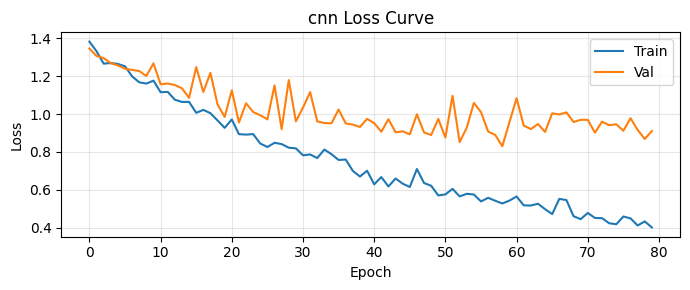


  1D-CNN
                     precision    recall  f1-score   support

    correct (<7deg)       0.72      0.63      0.67        49
     mild (7-10deg)       0.48      0.44      0.46        27
moderate (10-15deg)       0.33      0.62      0.43         8
    severe (>15deg)       0.76      0.79      0.77        28

           accuracy                           0.62       112
          macro avg       0.57      0.62      0.59       112
       weighted avg       0.64      0.62      0.63       112



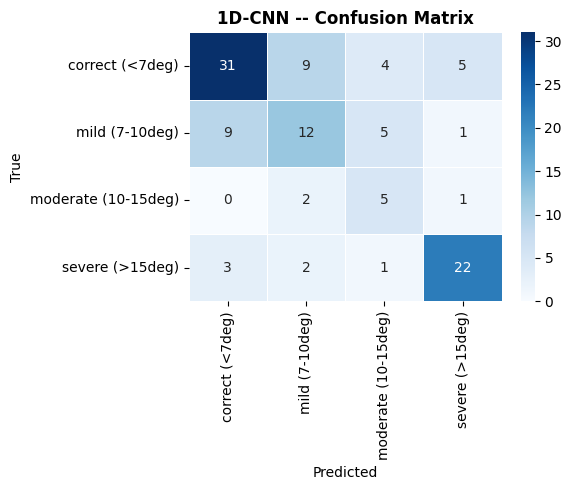

Saved -> cm_cnn.png
Macro F1: 0.586
Saved -> cnn_imu_only.pt


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
class_weight_tensor = torch.FloatTensor(class_weights).to(DEVICE)

class SquatCNN(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=5, padding=2), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32,   64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,   32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, n_classes),
        )
    def forward(self, x): return self.net(x)

def train_model(model, X_tr, y_tr, X_val, y_val, epochs=80, lr=1e-3, name='cnn'):
    model = model.to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit  = nn.CrossEntropyLoss(weight=class_weight_tensor)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=8, factor=0.5)

    Xt = torch.FloatTensor(X_tr).permute(0,2,1)
    yt = torch.LongTensor(y_tr)
    Xv = torch.FloatTensor(X_val).permute(0,2,1)
    yv = torch.LongTensor(y_val)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=16, shuffle=True)

    tl, vl, best, best_state = [], [], np.inf, None
    for ep in range(1, epochs+1):
        model.train()
        el = sum(
            (lambda xb, yb: (opt.zero_grad(),
                             loss := crit(model(xb.to(DEVICE)), yb.to(DEVICE)),
                             loss.backward(), opt.step(), loss.item())[4])(xb, yb)
            for xb, yb in loader
        ) / len(loader)
        model.eval()
        with torch.no_grad():
            vl_ = crit(model(Xv.to(DEVICE)), yv.to(DEVICE)).item()
        tl.append(el); vl.append(vl_); sched.step(vl_)
        if vl_ < best:
            best = vl_
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        if ep % 20 == 0:
            print(f'  Epoch {ep:3d}/{epochs} | train={el:.4f} val={vl_:.4f}')
    model.load_state_dict(best_state)

    plt.figure(figsize=(7,3))
    plt.plot(tl, label='Train'); plt.plot(vl, label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title(f'{name} Loss Curve'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f'loss_{name}.png', dpi=120); plt.show()
    return model

def predict_model(model, X_norm):
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_norm).permute(0,2,1).to(DEVICE))
    return logits.argmax(1).cpu().numpy()

n_classes = len(np.unique(y))
cnn = SquatCNN(in_ch=N_CHANNELS, n_classes=n_classes)
total_params = sum(p.numel() for p in cnn.parameters())
print(f'1D-CNN parameters: {total_params:,}')

cnn = train_model(cnn, X_train, y_train, X_test, y_test, epochs=80, name='cnn')
torch.save(cnn.state_dict(), 'cnn_imu_only.pt')
y_pred_cnn = predict_model(cnn, X_test)
evaluate('1D-CNN', y_test, y_pred_cnn, save_prefix='cnn')
print('Saved -> cnn_imu_only.pt')

LOSO Cross-Validation (8 subjects):
-------------------------------------------------------
  Epoch  20/60 | train=0.9381 val=1.8289
  Epoch  40/60 | train=0.6379 val=1.1169
  Epoch  60/60 | train=0.5835 val=1.2773


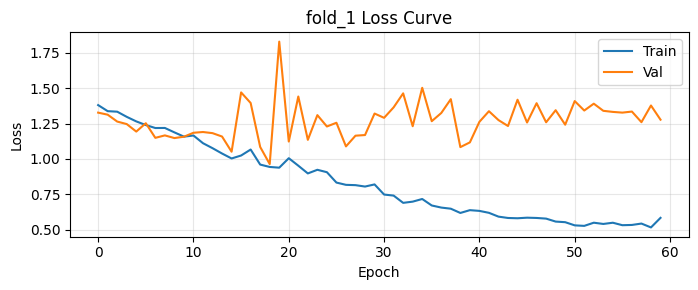

  Fold 1 (test=S01): macro F1=0.379 | dist={np.int64(0): 17, np.int64(1): 22, np.int64(3): 10}
  Epoch  20/60 | train=0.9017 val=2.1425
  Epoch  40/60 | train=0.7419 val=2.1986
  Epoch  60/60 | train=0.7424 val=2.3399


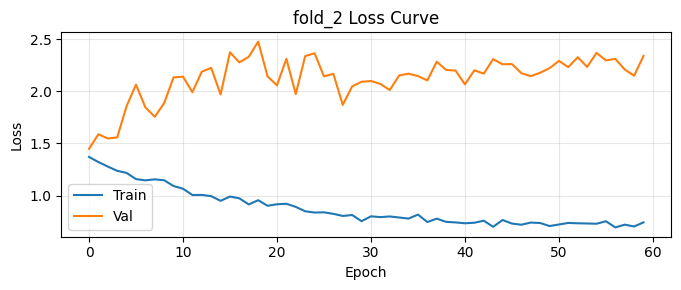

  Fold 2 (test=S02): macro F1=0.118 | dist={np.int64(0): 36, np.int64(1): 13, np.int64(2): 3, np.int64(3): 18}
  Epoch  20/60 | train=0.8299 val=2.3749
  Epoch  40/60 | train=0.6863 val=2.8023
  Epoch  60/60 | train=0.6528 val=2.8517


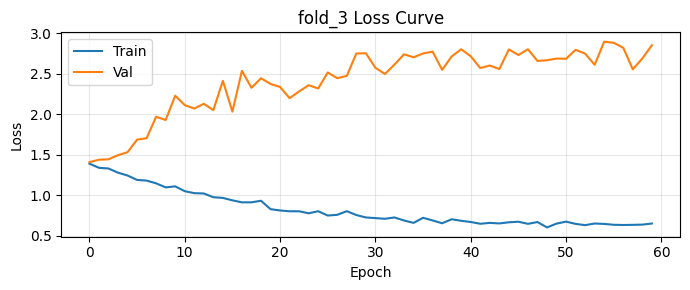

  Fold 3 (test=S03): macro F1=0.057 | dist={np.int64(0): 26, np.int64(1): 36, np.int64(2): 12, np.int64(3): 11}
  Epoch  20/60 | train=0.8471 val=3.2399
  Epoch  40/60 | train=0.6723 val=4.0526
  Epoch  60/60 | train=0.5911 val=4.6636


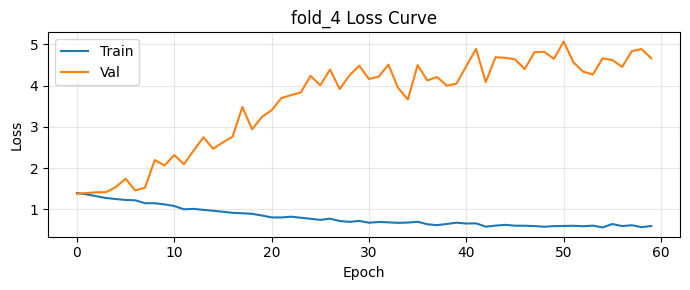

  Fold 4 (test=S04): macro F1=0.124 | dist={np.int64(0): 38, np.int64(1): 20, np.int64(2): 9, np.int64(3): 17}
  Epoch  20/60 | train=0.9542 val=1.5718
  Epoch  40/60 | train=0.7283 val=1.4009
  Epoch  60/60 | train=0.5338 val=1.3697


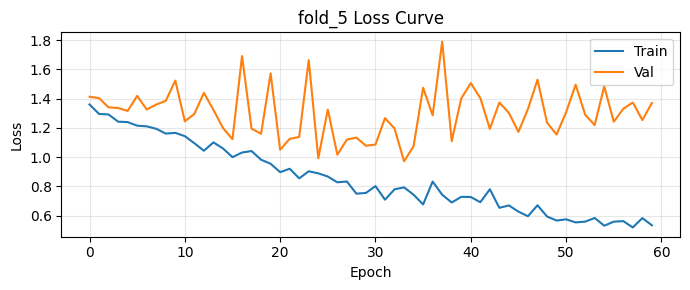

  Fold 5 (test=S05): macro F1=0.401 | dist={np.int64(0): 46, np.int64(1): 11, np.int64(2): 1, np.int64(3): 17}
  Epoch  20/60 | train=0.9196 val=1.1585
  Epoch  40/60 | train=0.7366 val=1.0649
  Epoch  60/60 | train=0.5484 val=1.0829


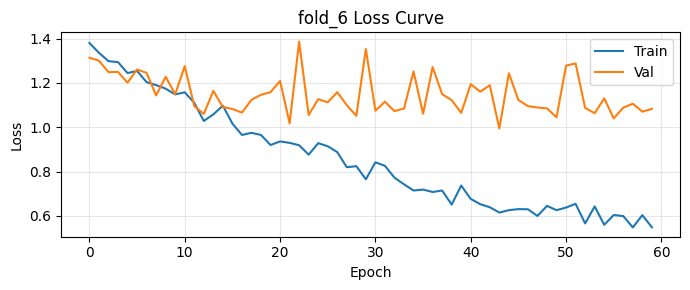

  Fold 6 (test=S06): macro F1=0.405 | dist={np.int64(0): 44, np.int64(1): 8, np.int64(3): 19}
  Epoch  20/60 | train=0.9146 val=1.9769
  Epoch  40/60 | train=0.7818 val=2.4926
  Epoch  60/60 | train=0.7281 val=2.5902


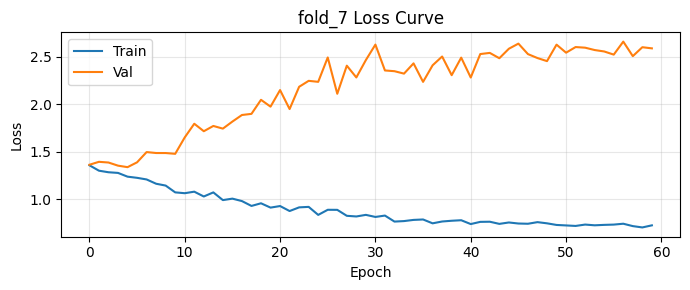

  Fold 7 (test=S07): macro F1=0.234 | dist={np.int64(0): 9, np.int64(1): 8, np.int64(2): 6, np.int64(3): 29}
  Epoch  20/60 | train=0.9222 val=2.0993
  Epoch  40/60 | train=0.7775 val=2.8457
  Epoch  60/60 | train=0.7138 val=3.0036


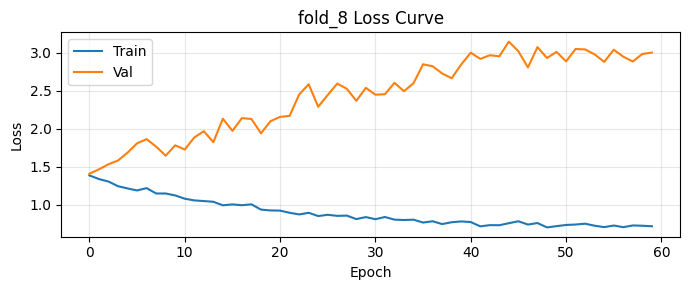

  Fold 8 (test=S08): macro F1=0.151 | dist={np.int64(0): 25, np.int64(1): 16, np.int64(2): 9, np.int64(3): 20}
-------------------------------------------------------
LOSO Mean F1: 0.234 +/- 0.133
Min: 0.057  Max: 0.405


In [9]:
# ── LOSO Cross-Validation for CNN/TCN ──────────────────────
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
loso_scores = []

print('LOSO Cross-Validation (8 subjects):')
print('-'*55)

for fold, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups=subjects)):
    subj_te = subjects[te_idx][0]

    if len(np.unique(y[te_idx])) < 2:
        print(f'  Fold {fold+1} ({subj_te}): skipped')
        continue

    # Normalize per fold
    sc_fold   = StandardScaler()
    X_tr_norm = sc_fold.fit_transform(
        X[tr_idx].reshape(len(tr_idx), T*C)).reshape(len(tr_idx), T, C)
    X_te_norm = sc_fold.transform(
        X[te_idx].reshape(len(te_idx), T*C)).reshape(len(te_idx), T, C)

    # Train fresh model per fold
    model_fold = SquatCNN(in_ch=N_CHANNELS, n_classes=N_CLASSES).to(DEVICE)  
    # swap SquatCNN for SquatTCN in TCN notebook
    model_fold = train_model(model_fold, X_tr_norm, y[tr_idx],
                              X_te_norm,  y[te_idx],
                              epochs=60, lr=1e-3, name=f'fold_{fold+1}')

    preds = predict_model(model_fold, X_te_norm)
    f1    = f1_score(y[te_idx], preds, average='macro', zero_division=0)
    loso_scores.append(f1)
    print(f'  Fold {fold+1} (test={subj_te}): macro F1={f1:.3f} | '
          f'dist={dict(sorted(Counter(y[te_idx]).items()))}')

print('-'*55)
print(f'LOSO Mean F1: {np.mean(loso_scores):.3f} +/- {np.std(loso_scores):.3f}')
print(f'Min: {np.min(loso_scores):.3f}  Max: {np.max(loso_scores):.3f}')